# **K-Nearest Neghbors from Scratch**

## 0.ライブラリのインポートとデータの生成

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split

# 分類
X_cls, y_cls = make_blobs(n_samples=300, centers=3, cluster_std=3.0, random_state=42)
X_cls_train, X_cls_test, y_cls_train, y_cls_test = train_test_split(X_cls, y_cls, test_size=0.4, random_state=42)

# 回帰
np.random.seed(42)
X_reg = np.sort(np.random.rand(100, 1) * 10, axis=0)
y_reg = np.sin(X_reg).ravel() + np.random.randn(100) * 0.3
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

## 1.アルゴリズム

分類：近いK個のラベルを多数決する  
回帰：近いK個の値を平均する

### 1.1.ユークリッド距離

2点間の直線距離。各次元の差の二乗を足して√をとる。

### 1.2.分類

①テストデータの各点について、学習データ全点との距離を計算  
②距離が近い順にK個のインデックスを取得(np.argsort)  
③K個のラベルを多数決(np.bincount、np.argmax)

### 1.3.回帰

①テストデータの各点について、学習データ全点との距離を計算  
②距離が近い順にK個のインデックスを取得(np.argsort)  
③K個の値を平均(np.mean)

In [16]:
def euclidean_distance(x1, x2):
  return np.sqrt(np.sum((x1 - x2)**2))

# 分類
def knn_classify(X_train, y_train, X_test, k=3):
  predictions = []
  for x in X_test:
    distances = [euclidean_distance(x, x_train) for x_train in X_train]
    k_indices = np.argsort(distances)[:k]
    k_labels = y_train[k_indices]
    pred = np.argmax(np.bincount(k_labels))
    predictions.append(pred)
  return np.array(predictions)

# 回帰
def knn_regress(X_train, y_train, X_test, k=3):
  predictions = []
  for x in X_test:
    distances = [euclidean_distance(x, x_train) for x_train in X_train]
    k_indices = np.argsort(distances)[:k]
    pred = np.mean(y_train[k_indices])
    predictions.append(pred)
  return np.array(predictions)

## 2.モデルの可視化

### 2.1.分類

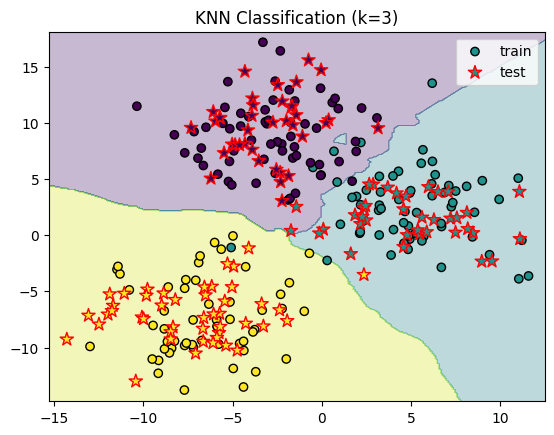

In [17]:
x_min, x_max = X_cls[:, 0].min() - 1, X_cls[:, 0].max() + 1
y_min, y_max = X_cls[:, 1].min() - 1, X_cls[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1), np.arange(y_min, y_max, 0.1))
grid = np.c_[xx.ravel(), yy.ravel()]
Z = knn_classify(X_cls_train, y_cls_train, grid, k=3)
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, alpha=0.3)
plt.scatter(X_cls_train[:, 0], X_cls_train[:, 1], c=y_cls_train, edgecolors='k', label='train')
plt.scatter(X_cls_test[:, 0], X_cls_test[:, 1], c=y_cls_test, edgecolors='r', marker='*', s=100, label='test')
plt.title("KNN Classification (k=3)")
plt.legend()
plt.show()

### 2.2.回帰

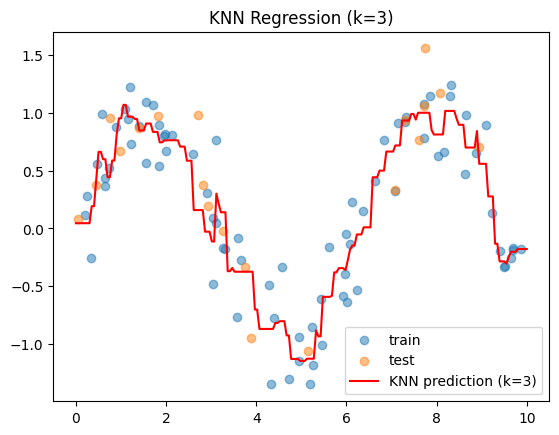

In [18]:
X_plot = np.linspace(0, 10, 200).reshape(-1, 1)
y_plot = knn_regress(X_reg_train, y_reg_train, X_plot, k=3)

plt.scatter(X_reg_train, y_reg_train, label='train', alpha=0.5)
plt.scatter(X_reg_test, y_reg_test, label='test', alpha=0.5)
plt.plot(X_plot, y_plot, color='red', label='KNN prediction (k=3)')
plt.title("KNN Regression (k=3)")
plt.legend()
plt.show()

## 3.検証

### 3.1.分類：精度

In [19]:
y_cls_pred = knn_classify(X_cls_train, y_cls_train, X_cls_test, k=3)
accuracy = np.sum(y_cls_pred == y_cls_test) / len(y_cls_test)
print(f"Accuracy (k=3): {accuracy:.3f}")

Accuracy (k=3): 0.975


### 3.2.分類：K比較

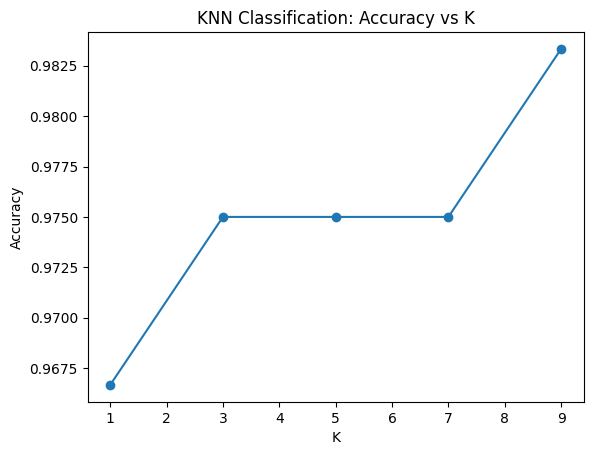

In [20]:
k_values = [1, 3, 5, 7, 9]
accuracies = []
for k in k_values:
  y_pred = knn_classify(X_cls_train, y_cls_train, X_cls_test, k=k)
  acc = np.sum(y_pred == y_cls_test) / len(y_cls_test)
  accuracies.append(acc)

plt.plot(k_values, accuracies, marker='o')
plt.xlabel("K")
plt.ylabel("Accuracy")
plt.title("KNN Classification: Accuracy vs K")
plt.show()

### 3.3.回帰：MSE

予測値と実際の値の差を二乗して平均したもので、値が小さいほど予測精度が高い。

In [21]:
y_reg_pred = knn_regress(X_reg_train, y_reg_train, X_reg_test, k=3)
mse = np.mean((y_reg_pred - y_reg_test)**2)
print(f"MSE (k=3): {mse:.3f}")

MSE (k=3): 0.106
